###Import di librerie e dataset

In [ ]:
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf
import matplotlib.pyplot as plt
import imblearn
from sklearn.preprocessing import LabelEncoder
from collections import Counter
from imblearn.over_sampling import SMOTE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset = pd.read_csv('/content/drive/MyDrive/mergedResNet34TrainingCONCAT.csv')

dataset.head(2)

,Unnamed: 0,Unnamed: 0.1,f0,f1,f2,f3,f4,f5,f6,f7,...,f505,f506,f507,f508,f509,f510,f511,images,cone_name,label
0,0,0,0.878583,0.798011,1.032221,1.025648,0.932683,0.942697,1.145143,0.899828,...,1.018030,0.716998,0.831250,0.967619,0.828388,0.796302,0.869872,cone35_frame0046_0,cone35_frame0046_0,2
1,1,1,0.789336,0.987613,0.985949,0.994959,0.855062,0.964386,1.030023,0.886103,...,1.152784,0.850843,0.912317,0.947074,0.869836,0.876474,0.877852,cone35_frame0046_1,cone35_frame0046_1,2


In [ ]:
dataset1 = dataset.drop(['Unnamed: 0', 'Unnamed: 0.1', 'images', 'cone_name'], axis=1)

dataset1.head(2)

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f503,f504,f505,f506,f507,f508,f509,f510,f511,label
0,0.878583,0.798011,1.032221,1.025648,0.932683,0.942697,1.145143,0.899828,1.105560,0.982394,...,0.940622,0.848088,1.018030,0.716998,0.831250,0.967619,0.828388,0.796302,0.869872,2
1,0.789336,0.987613,0.985949,0.994959,0.855062,0.964386,1.030023,0.886103,0.992618,1.063324,...,0.875840,0.851216,1.152784,0.850843,0.912317,0.947074,0.869836,0.876474,0.877852,2


###Splitting e data trasformation

In [ ]:
#Splitting 80-20, where 20 is the test set
firstsplit = dataset1.sample(frac = 0.80, random_state = 100)
test = dataset1.drop(firstsplit.index)

#Splitting of the remaining 80 in 75-25, where 75 is the training set and 25 the validation set
train = firstsplit.sample(frac = 0.75, random_state = 100)
validation = firstsplit.drop(train.index)

print(len(train))
print(len(test))
print(len(validation))

6702
2234
2234


In [ ]:
# Removing the column 'label' from each set

trainlabel = train.pop('label')
testlabel = test.pop('label')
validlabel = validation.pop('label')

print(trainlabel.shape, testlabel.shape, validlabel.shape)

(6702,) (2234,) (2234,)


In [ ]:
# Check on the class distribution in the training set

trainlabel = LabelEncoder().fit_transform(trainlabel)

counter = Counter(trainlabel)

for k,v in counter.items():
 per = v / len(trainlabel) * 100
 print('Class=%d, n=%d (%.3f%%)' % (k+1, v, per))

Class=1, n=927 (13.832%)
Class=4, n=2519 (37.586%)
Class=2, n=2340 (34.915%)
Class=3, n=916 (13.668%)


In [ ]:
# Application of SMOTE on the training set

oversample = SMOTE()

train, trainlabel = oversample.fit_resample(train, trainlabel)

counter = Counter(trainlabel)

for k,v in counter.items():
 per = v / len(trainlabel) * 100
 print('Class=%d, n=%d (%.3f%%)' % (k+1, v, per))

Class=1, n=2519 (25.000%)
Class=4, n=2519 (25.000%)
Class=2, n=2519 (25.000%)
Class=3, n=2519 (25.000%)


In [ ]:
x = train.values

x_val = validation.values

print(x, x_val)

In [ ]:
validlabel = LabelEncoder().fit_transform(validlabel)

x_val_lbl = validlabel

x_val_lbl1 = pd.get_dummies(x_val_lbl)

x_val_lbl2 = x_val_lbl1.values

In [ ]:
x_lbl = trainlabel

x_lbl1 = pd.get_dummies(x_lbl)

x_lbl2 = x_lbl1.values

###Implementazione del modello per la fase di valutazione delle performance

In [ ]:
def modelML():
  model = Sequential()

  model.add(Dense(512, input_dim = 512, activation = 'relu'))

  model.add(tf.keras.layers.Dropout(0.3))

  model.add(Dense(4, activation = 'softmax'))

  optimizer = tf.keras.optimizers.SGD(learning_rate=0.001,momentum=0.7)

  model.compile(loss = 'categorical_crossentropy', optimizer = optimizer, metrics = ['accuracy'])

  return model

In [ ]:
modelMLCall = modelML()

import time
class SOMT(tf.keras.callbacks.Callback):
    def __init__(self, model,  train_thold, valid_thold):
        super(SOMT, self).__init__()
        self.model=model
        self.train_thold=train_thold
        self.valid_thold=valid_thold

    def on_train_begin(self, logs=None):
        print('Starting Training - training will halt if training accuracy achieves or exceeds ', self.train_thold)
        print ('and validation accuracy meets or exceeds ', self.valid_thold)
        msg='{0:^8s}{1:^12s}{2:^12s}{3:^12s}{4:^12s}{5:^12s}'.format('Epoch', 'Train Acc', 'Train Loss','Valid Acc','Valid_Loss','Duration')
        print (msg)

    def on_train_batch_end(self, batch, logs=None):
        acc=logs.get('accuracy')* 100  # get training accuracy
        loss=logs.get('loss')
        msg='{0:1s}processed batch {1:4s}  training accuracy= {2:8.3f}  loss: {3:8.5f}'.format(' ', str(batch),  acc, loss)
        print(msg, '\r', end='')

    def on_epoch_begin(self,epoch, logs=None):
        self.now= time.time()

    def on_epoch_end(self,epoch, logs=None):
        later=time.time()
        duration=later-self.now
        tacc=logs.get('accuracy')
        vacc=logs.get('val_accuracy')
        tr_loss=logs.get('loss')
        v_loss=logs.get('val_loss')
        ep=epoch+1
        print(f'{ep:^8.0f} {tacc:^12.2f}{tr_loss:^12.4f}{vacc:^12.2f}{v_loss:^12.4f}{duration:^12.2f}')
        if tacc>= self.train_thold and vacc>= self.valid_thold:
            print( f'\ntraining accuracy and validation accuracy reached the thresholds on epoch {epoch + 1}' )
            self.model.stop_training = True # stop training


train_thold= .93
valid_thold=.91
callbacks=[SOMT(modelMLCall, train_thold, valid_thold)]


fitting = modelMLCall.fit(x, x_lbl2, validation_data = (x_val, x_val_lbl2), batch_size=128, epochs = 500, callbacks=callbacks, verbose=0)

Starting Training - training will halt if training accuracy achieves or exceeds  0.93
and validation accuracy meets or exceeds  0.91
 Epoch   Train Acc   Train Loss  Valid Acc   Valid_Loss   Duration  
   1         0.25       1.5371       0.31       1.3756       1.23    
   2         0.26       1.4616       0.14       1.4230       0.71    
   3         0.27       1.4290       0.17       1.3888       0.75    
   4         0.28       1.4097       0.35       1.3626       0.73    
   5         0.30       1.3879       0.43       1.3490       0.73    
   6         0.30       1.3738       0.55       1.3346       0.74    
   7         0.31       1.3650       0.28       1.3713       0.68    
   8         0.33       1.3564       0.47       1.3051       0.77    
   9         0.34       1.3472       0.52       1.3047       0.68    
   10        0.35       1.3434       0.67       1.3030       0.75    
   11        0.37       1.3351       0.44       1.3413       0.69    
   12        0.40       1.32

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


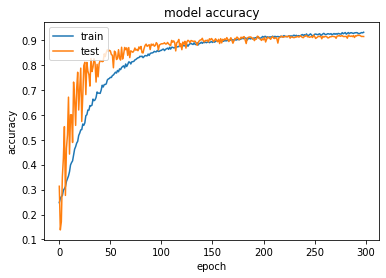

In [ ]:
# list all data in history
print(fitting.history.keys())
# summarize history for accuracy

plt.plot(fitting.history['accuracy'])
plt.plot(fitting.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
ymax = max(fitting.history['accuracy'])
ymaxval = max(fitting.history['val_accuracy'])
print(ymax, ymaxval)

0.9307264685630798 0.9189794063568115


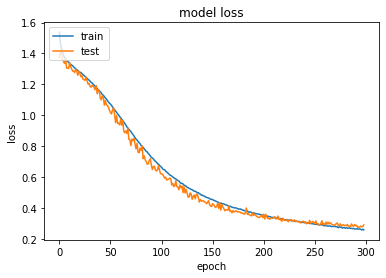

In [ ]:
# summarize history for loss
plt.plot(fitting.history['loss'])
plt.plot(fitting.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
y_testlabel = LabelEncoder().fit_transform(testlabel)
y_dummylabel = pd.get_dummies(y_testlabel)
y_lblvalues = y_dummylabel.values

y = test.values



testeval = modelMLCall.evaluate(y,y_lblvalues)

70/70 [==============================] - 0s 3ms/step - loss: 0.2378 - accuracy: 0.9252


### Import del test set per le predizioni

In [ ]:
testSet = pd.read_csv('/content/drive/MyDrive/TEST.csv', sep = ';')

testSet.head(2)

,Unnamed: 0,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f503,f504,f505,f506,f507,f508,f509,f510,f511,image
0,0,0.911863,0.952458,1.085506,0.910698,0.880114,1.016642,0.934292,1.024749,1.228008,...,0.874452,0.974516,1.105526,0.824213,0.847534,1.071275,0.944886,0.901812,0.883428,img_1
1,1,0.843607,0.855531,1.043309,0.820285,0.940399,0.884501,0.982856,0.809213,1.116383,...,0.928182,0.858758,1.086330,0.816912,0.809086,1.059228,1.033703,1.001865,0.824272,img_2


In [ ]:
testdrop = testSet.drop(['Unnamed: 0'], axis=1)

testdrop.head(3)

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f503,f504,f505,f506,f507,f508,f509,f510,f511,image
0,0.911863,0.952458,1.085506,0.910698,0.880114,1.016642,0.934292,1.024749,1.228008,0.951209,...,0.874452,0.974516,1.105526,0.824213,0.847534,1.071275,0.944886,0.901812,0.883428,img_1
1,0.843607,0.855531,1.043309,0.820285,0.940399,0.884501,0.982856,0.809213,1.116383,1.116935,...,0.928182,0.858758,1.086330,0.816912,0.809086,1.059228,1.033703,1.001865,0.824272,img_2
2,0.916222,0.942230,1.002605,1.082436,0.911001,1.070029,1.015654,0.989635,1.155890,0.921690,...,0.979656,0.841254,0.985832,0.742647,0.816151,0.949110,0.962458,0.944196,0.901135,img_3


In [ ]:
testImg = testdrop.pop('image')

testImg.head(3)

0    img_1
1    img_2
2    img_3
Name: image, dtype: object

In [ ]:
datalabel = dataset1.pop('label')

In [ ]:
xdata = dataset1.copy()

xdata.head(2)

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f502,f503,f504,f505,f506,f507,f508,f509,f510,f511
0,0.878583,0.798011,1.032221,1.025648,0.932683,0.942697,1.145143,0.899828,1.105560,0.982394,...,0.799881,0.940622,0.848088,1.018030,0.716998,0.831250,0.967619,0.828388,0.796302,0.869872
1,0.789336,0.987613,0.985949,0.994959,0.855062,0.964386,1.030023,0.886103,0.992618,1.063324,...,0.838019,0.875840,0.851216,1.152784,0.850843,0.912317,0.947074,0.869836,0.876474,0.877852


In [ ]:
ydata = datalabel.copy()

ydata.head(2)

0    2
1    2
Name: label, dtype: int64

In [ ]:
xdata1 = xdata.values
ydata = pd.get_dummies(ydata)
ydata1 = ydata.values

### Implementazione del modello per le predizioni

In [ ]:
def modelML2():
  model = Sequential()

  model.add(Dense(512, input_dim = 512, activation = 'relu'))



  model.add(Dense(4, activation = 'softmax'))

  optimizer = tf.keras.optimizers.SGD(learning_rate=0.001,momentum=0.7)

  model.compile(loss = 'categorical_crossentropy', optimizer = optimizer, metrics = ['accuracy'])

  return model


modelMLCall2 = modelML2()


import time
class SOMT(tf.keras.callbacks.Callback):
    def __init__(self, model, loss_thold):
        super(SOMT, self).__init__()
        self.model=model
        self.loss_thold=loss_thold

    def on_train_begin(self, logs=None):
        print('Starting Training - training will halt if training loss goes below ', self.loss_thold)
        msg='{0:^8s}{1:^12s}{2:^12s}{3:^12s}'.format('Epoch', 'Train Acc', 'Train Loss','Duration')
        print (msg)

    def on_train_batch_end(self, batch, logs=None):
        acc=logs.get('accuracy')* 100  # get training accuracy
        loss=logs.get('loss')
        msg='{0:1s}processed batch {1:4s}  training accuracy= {2:8.3f}  loss: {3:8.5f}'.format(' ', str(batch),  acc, loss)
        print(msg, '\r', end='') # prints over on the same line to show running batch count

    def on_epoch_begin(self,epoch, logs=None):
        self.now= time.time()

    def on_epoch_end(self,epoch, logs=None):
        later=time.time()
        duration=later-self.now
        tacc=logs.get('accuracy')
        tr_loss=logs.get('loss')
        ep=epoch+1
        print(f'{ep:^8.0f} {tacc:^12.2f}{tr_loss:^12.4f}{duration:^12.2f}')
        if tr_loss<= self.loss_thold:
            print( f'\nTraining loss went below the threshold of 0.205 on epoch {epoch + 1}' )
            self.model.stop_training = True # stop training


loss_thold = .205
callbacks=[SOMT(modelMLCall2, loss_thold)]



fitting2 = modelMLCall2.fit(xdata1, ydata1, batch_size=128, epochs = 500, callbacks=callbacks, verbose=0)

Starting Training - training will halt if training loss goes below  0.205
 Epoch   Train Acc   Train Loss   Duration  
   1         0.37       1.2864       0.92    
   2         0.41       1.2658       0.63    
   3         0.44       1.2563       0.61    
   4         0.46       1.2494       0.61    
   5         0.48       1.2414       0.61    
   6         0.49       1.2333       0.59    
   7         0.54       1.2240       0.60    
   8         0.55       1.2171       0.60    
   9         0.55       1.2104       0.62    
   10        0.56       1.2006       0.61    
   11        0.57       1.1938       0.63    
   12        0.61       1.1845       0.61    
   13        0.61       1.1767       0.60    
   14        0.62       1.1697       0.62    
   15        0.63       1.1603       0.63    
   16        0.64       1.1512       0.60    
   17        0.66       1.1416       0.62    
   18        0.65       1.1341       0.60    
   19        0.66       1.1244       0.61    
   20  

In [ ]:
prediction = modelMLCall2.predict(testdrop)


prediction_rounded = [np.round(x) for x in prediction]


prediction_class = [np.argmax(x) + 1 for x in prediction_rounded]
print(prediction_class)

199/199 [==============================] - 0s 2ms/step
[4, 4, 2, 1, 3, 1, 1, 1, 1, 1, 1, 4, 4, 1, 1, 4, 2, 2, 4, 4, 2, 2, 4, 4, 2, 2, 2, 4, 4, 4, 2, 2, 2, 4, 4, 4, 2, 2, 2, 1, 4, 4, 4, 4, 2, 2, 2, 1, 4, 4, 4, 2, 2, 2, 1, 4, 4, 4, 2, 2, 4, 4, 2, 4, 4, 4, 1, 1, 1, 4, 1, 4, 1, 1, 4, 1, 4, 1, 4, 4, 2, 2, 3, 3, 3, 1, 2, 3, 3, 3, 3, 2, 3, 3, 1, 3, 2, 3, 1, 3, 3, 2, 3, 3, 3, 1, 2, 3, 1, 3, 3, 2, 3, 3, 3, 3, 2, 3, 3, 3, 3, 2, 2, 3, 3, 3, 3, 3, 3, 1, 2, 2, 2, 4, 4, 2, 4, 4, 2, 2, 2, 2, 4, 4, 2, 2, 4, 4, 4, 2, 2, 4, 4, 4, 2, 4, 4, 2, 2, 4, 4, 2, 4, 4, 2, 4, 4, 2, 4, 2, 4, 4, 4, 2, 1, 4, 4, 2, 2, 1, 4, 4, 2, 1, 2, 2, 2, 4, 2, 2, 4, 4, 2, 2, 4, 2, 2, 2, 4, 4, 2, 4, 2, 4, 1, 2, 2, 4, 4, 2, 2, 4, 2, 2, 4, 2, 2, 4, 4, 2, 4, 4, 2, 2, 4, 4, 2, 4, 4, 2, 4, 2, 1, 1, 1, 4, 4, 3, 1, 4, 3, 1, 4, 1, 1, 1, 1, 4, 1, 1, 1, 1, 4, 1, 1, 4, 1, 1, 4, 1, 1, 4, 4, 2, 2, 4, 1, 3, 3, 3, 1, 3, 1, 4, 2, 2, 3, 3, 3, 1, 3, 3, 4, 4, 2, 2, 3, 3, 4, 3, 2, 2, 3, 3, 4, 1, 2, 4, 4, 2, 4, 4, 2, 1, 4, 4, 4, 2, 2, 1, 4, 4, 2, 2, 1,

In [ ]:
submission = pd.DataFrame({'ID':testImg,'Class':prediction_class})

print(submission.head(5))

print(submission.shape)

      ID  Class
0  img_1      4
1  img_2      4
2  img_3      2
3  img_4      1
4  img_5      3
(6347, 2)


In [ ]:
submission.to_csv('/content/drive/MyDrive/submission.csv', index = False)